# BBBC021 dataset exploration



In [30]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import torch
from IPython.display import display
from types import SimpleNamespace

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root)) if str(project_root) not in sys.path else None

from src.preprocessing import eval_transform
from src.splitting import create_loco_folds, create_validation_split

ANALYSIS_DIR = project_root / "analysis"
OUT = ANALYSIS_DIR / "eda"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 200, "axes.spines.top": False, "axes.spines.right": False})

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

image_path = project_root / "data/raw/BBBC021_v1_image.csv"
moa_path = project_root / "data/raw/BBBC021_v1_moa.csv"

images = pd.read_csv(image_path)
annotations = pd.read_csv(moa_path)

joined = images.merge(
    annotations, how="left", validate="many_to_one",
    left_on=["Image_Metadata_Compound", "Image_Metadata_Concentration"],
    right_on=["compound", "concentration"], indicator=True
)

metadata = joined.loc[joined["moa"].notna() & joined["moa"].ne("DMSO")].copy()
metadata = metadata.drop(columns="_merge").reset_index(drop=True)

classes = sorted(metadata.moa.unique())


## Looking at subset size and class balance

project uses supervised learning to train model to recognise MoA from microscopy image, so only the images with annotated MoAs were retained. The resulting dataset is therefore a subset of the original BBBC021. Image counts, compound counts, and class counts are important to know.

,count
raw_fields_of_view,13200
unannotated_fields_of_view,9352
annotated_DMSO_fields_of_view,1320
included_fields_of_view,2528
compounds,38
MoAs,12


,images,compounds,treatments
moa,,,
Actin disruptors,60,3,5
Aurora kinase inhibitors,144,3,12
Cholesterol-lowering,72,2,6
DNA damage,108,4,9
DNA replication,96,4,8
Eg5 inhibitors,144,2,12
Epithelial,88,3,8
Kinase inhibitors,40,3,5
Microtubule destabilizers,168,4,14


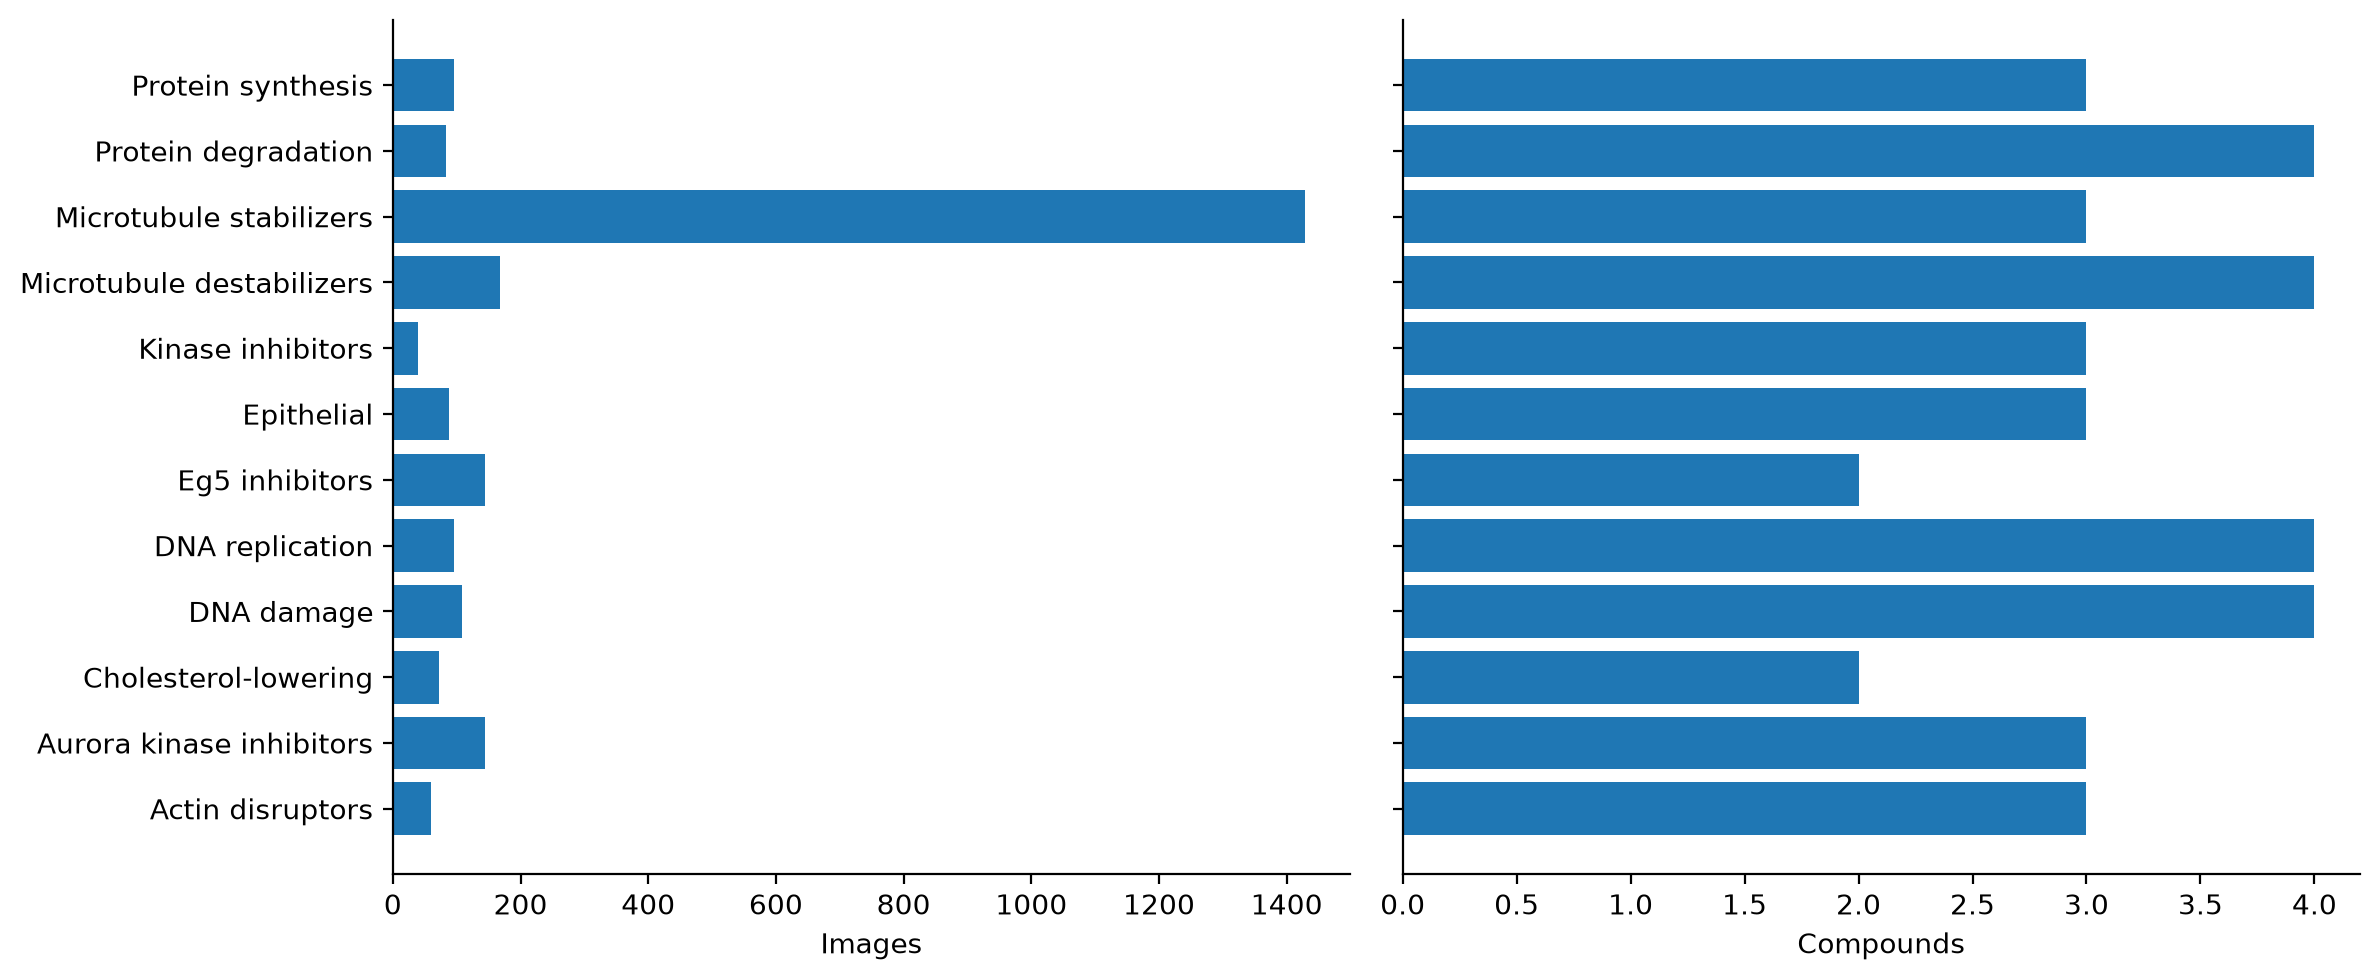

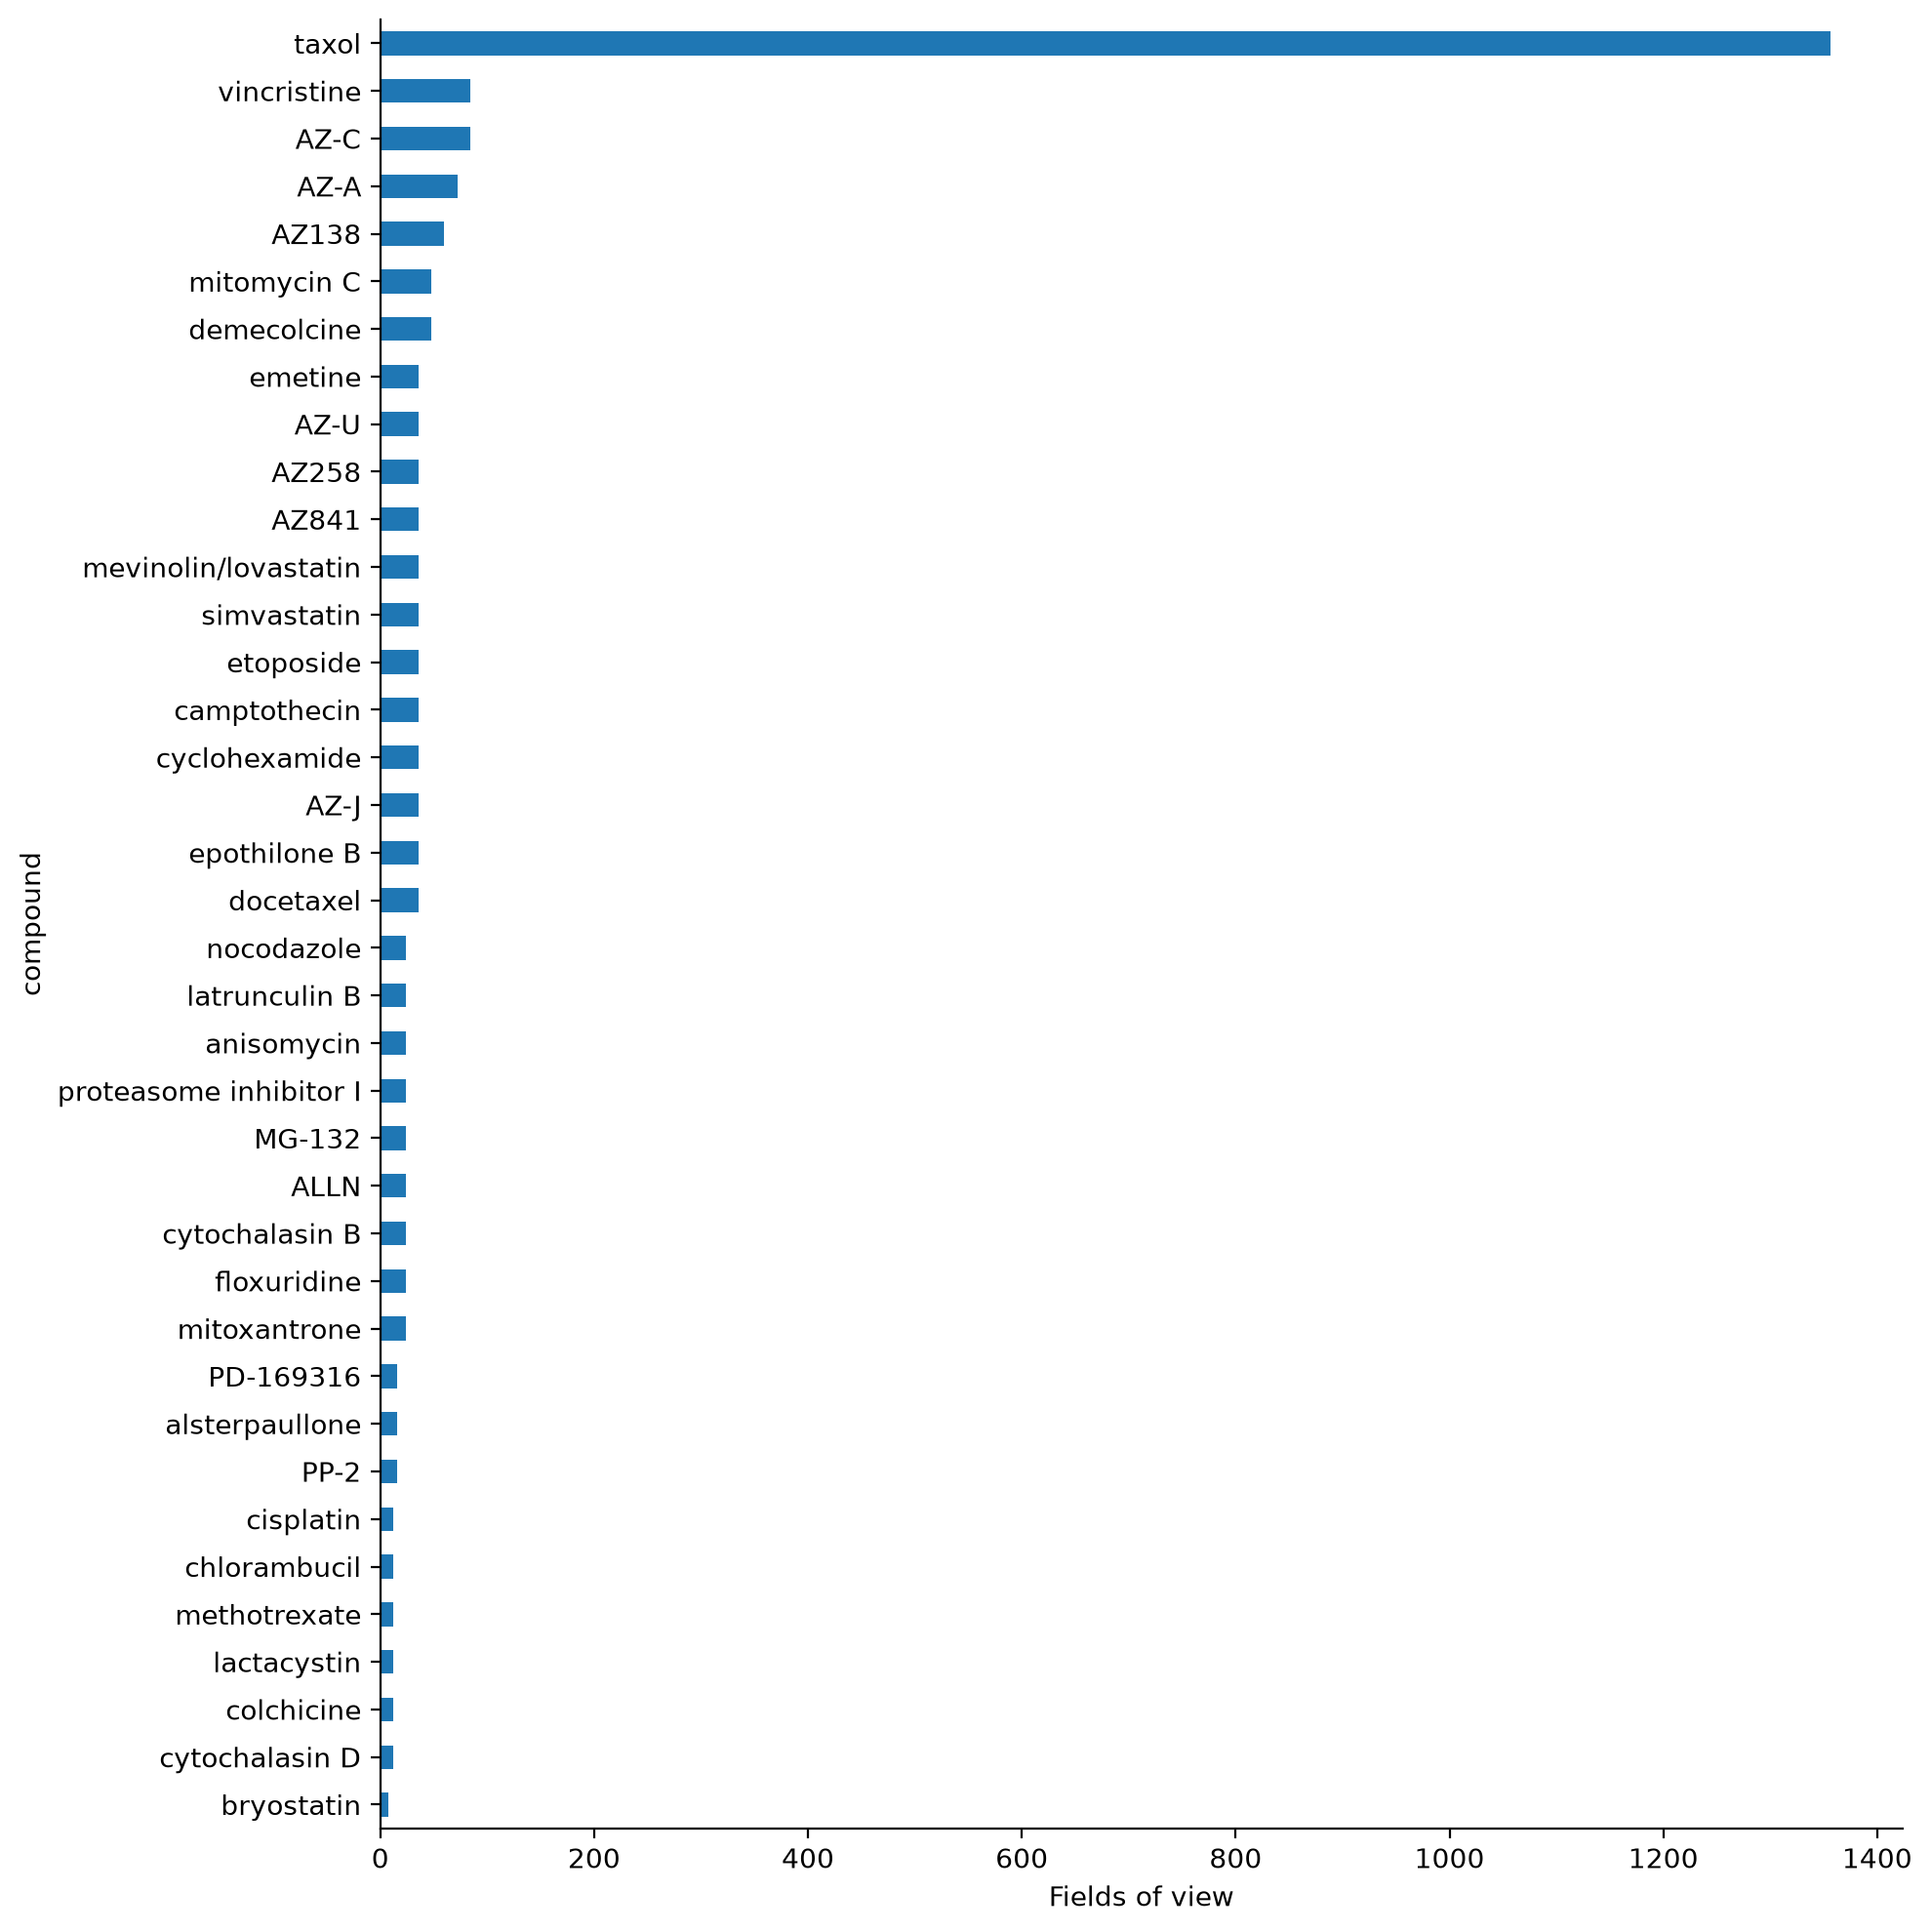

Taxol share of images: 53.6%


In [31]:
inventory = pd.Series({
    "raw_fields_of_view": len(images),
    "unannotated_fields_of_view": int(joined.moa.isna().sum()),
    "annotated_DMSO_fields_of_view": int(joined.moa.eq("DMSO").sum()),
    "included_fields_of_view": len(metadata),
    "compounds": metadata.Image_Metadata_Compound.nunique(),
    "MoAs": len(classes),
}, name="count")

display(inventory.to_frame())

class_counts = metadata.groupby("moa").agg(
    images=("moa", "size"), compounds=("compound", "nunique"))
class_counts["treatments"] = metadata.drop_duplicates(
    ["compound", "concentration"]).groupby("moa").size()
display(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, column in zip(axes, ["images", "compounds"]):
    ax.barh(class_counts.index, class_counts[column])
    ax.set_xlabel(column.capitalize())
savefig(fig, "class_balance")

compound_counts = metadata.groupby(["moa", "compound"]).size().rename("images")
fig, ax = plt.subplots(figsize=(10, 10))
compound_counts.sort_values().reset_index().plot.barh(
    x="compound", y="images", ax=ax, legend=False)
ax.set_xlabel("Fields of view")
savefig(fig, "compound_balance")



print("Taxol share of images:", f"{metadata.compound.eq('taxol').mean():.1%}")


The supervised subset contains 2,528 three-channel fields of view from 38 compounds and 12 MoA classes.

There can be seen that Taxol accounts for 53.6% of the dataset, resulting in the microtubule-stabiliser class to dominate image counts. This is a significant imbalance in the data and motivates the use of class-weighted cross-entropy during training and reporting of macro F1 and balanced accuracy as these metrics reduce the influence of large classes.

The significantly smaller MoA labelled dataset also prompt the use of transfer learning on an ImageNet-pretrained CNN model rather than training a deep model entirely from random initialisation.

## Quick look at some MoA field of views

Each displayed channel is independently scaled to its 1st-99th percentiles for visibility.

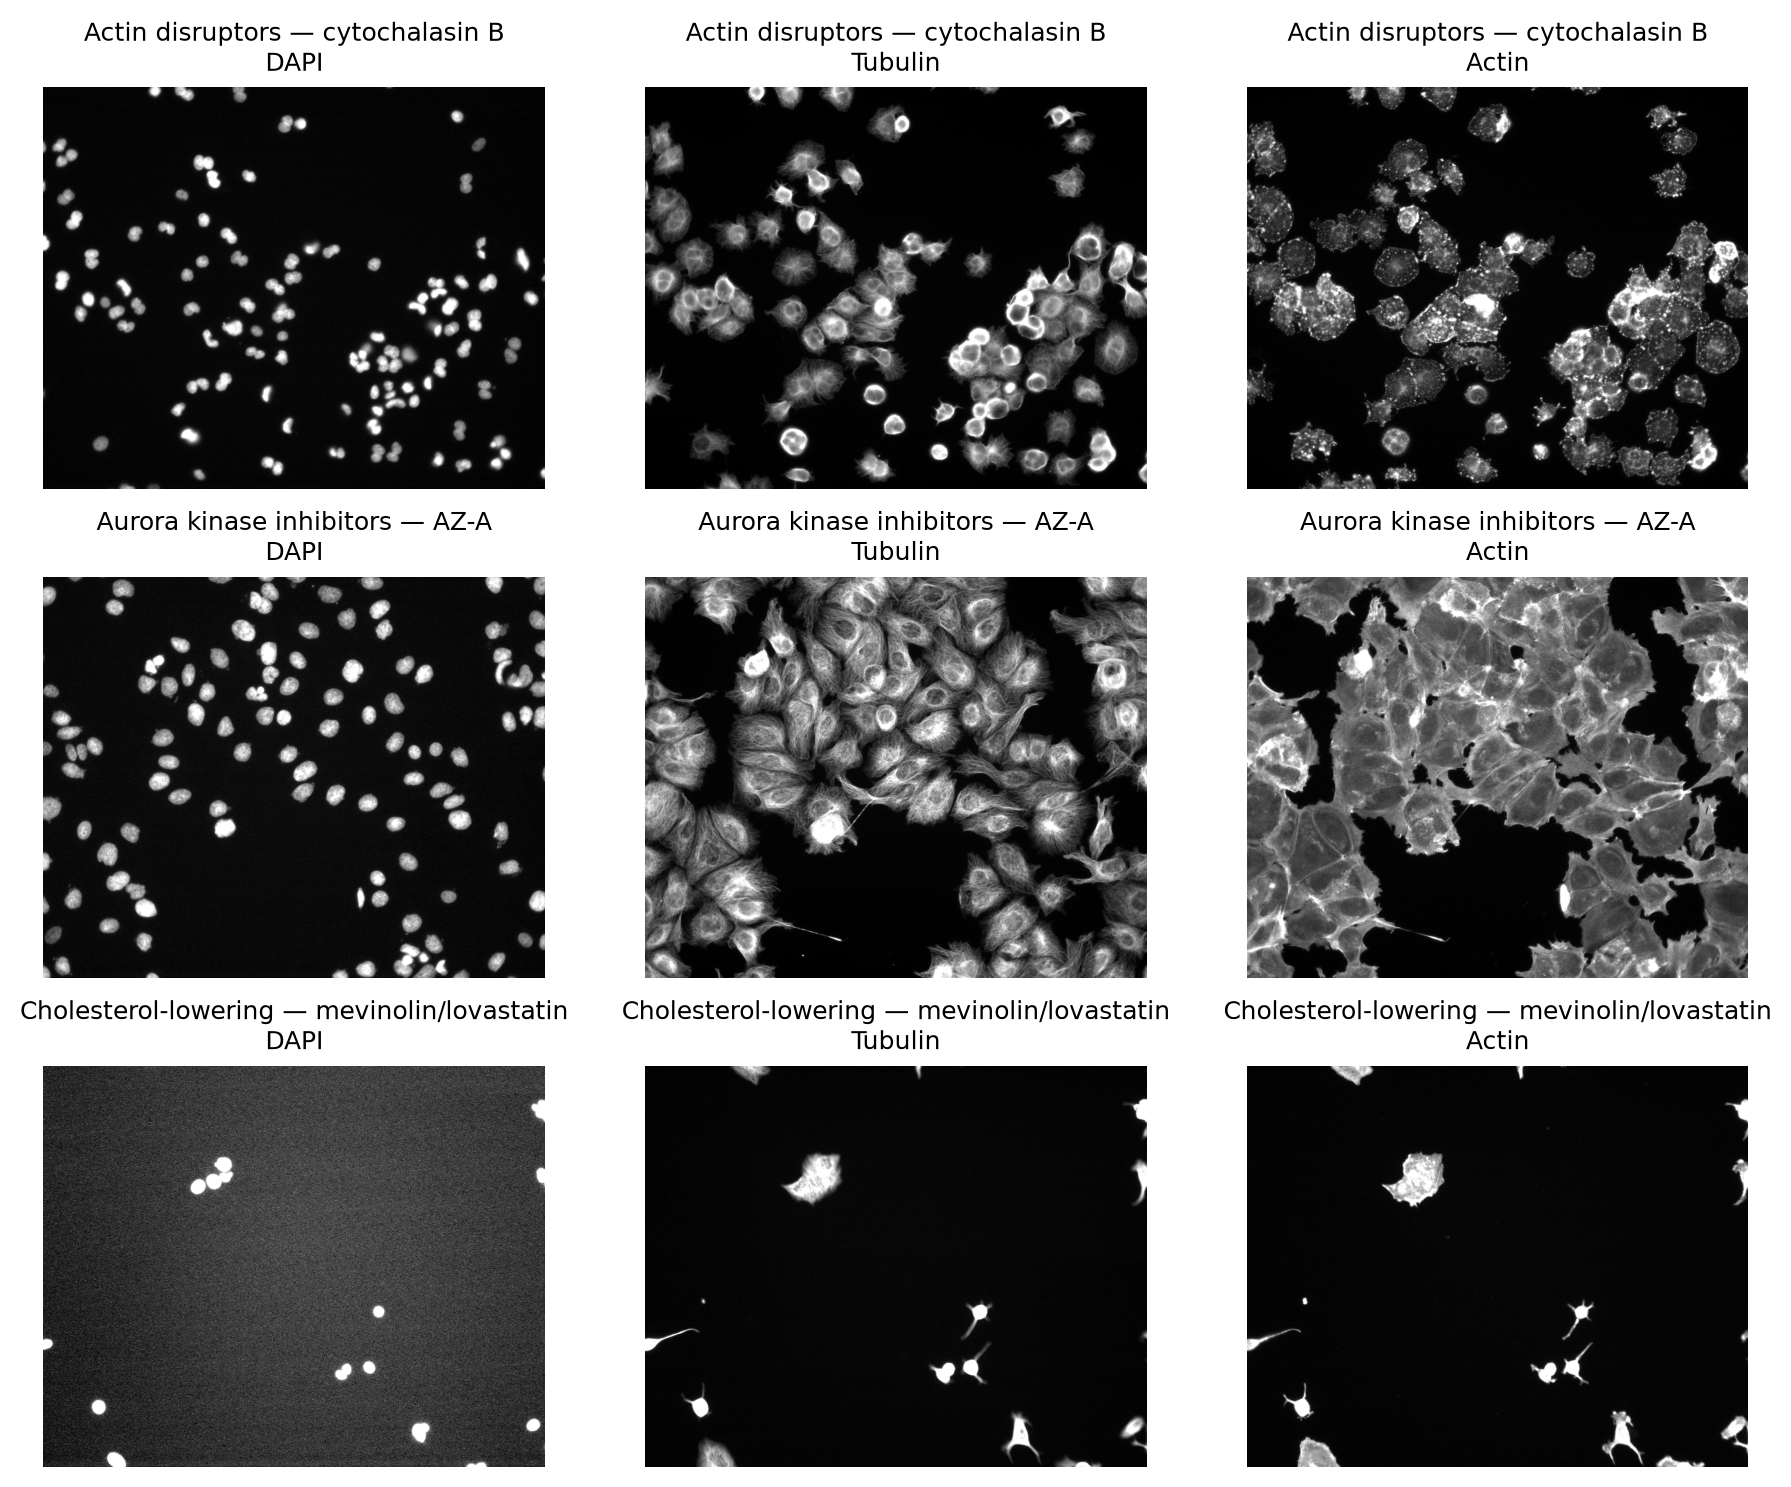

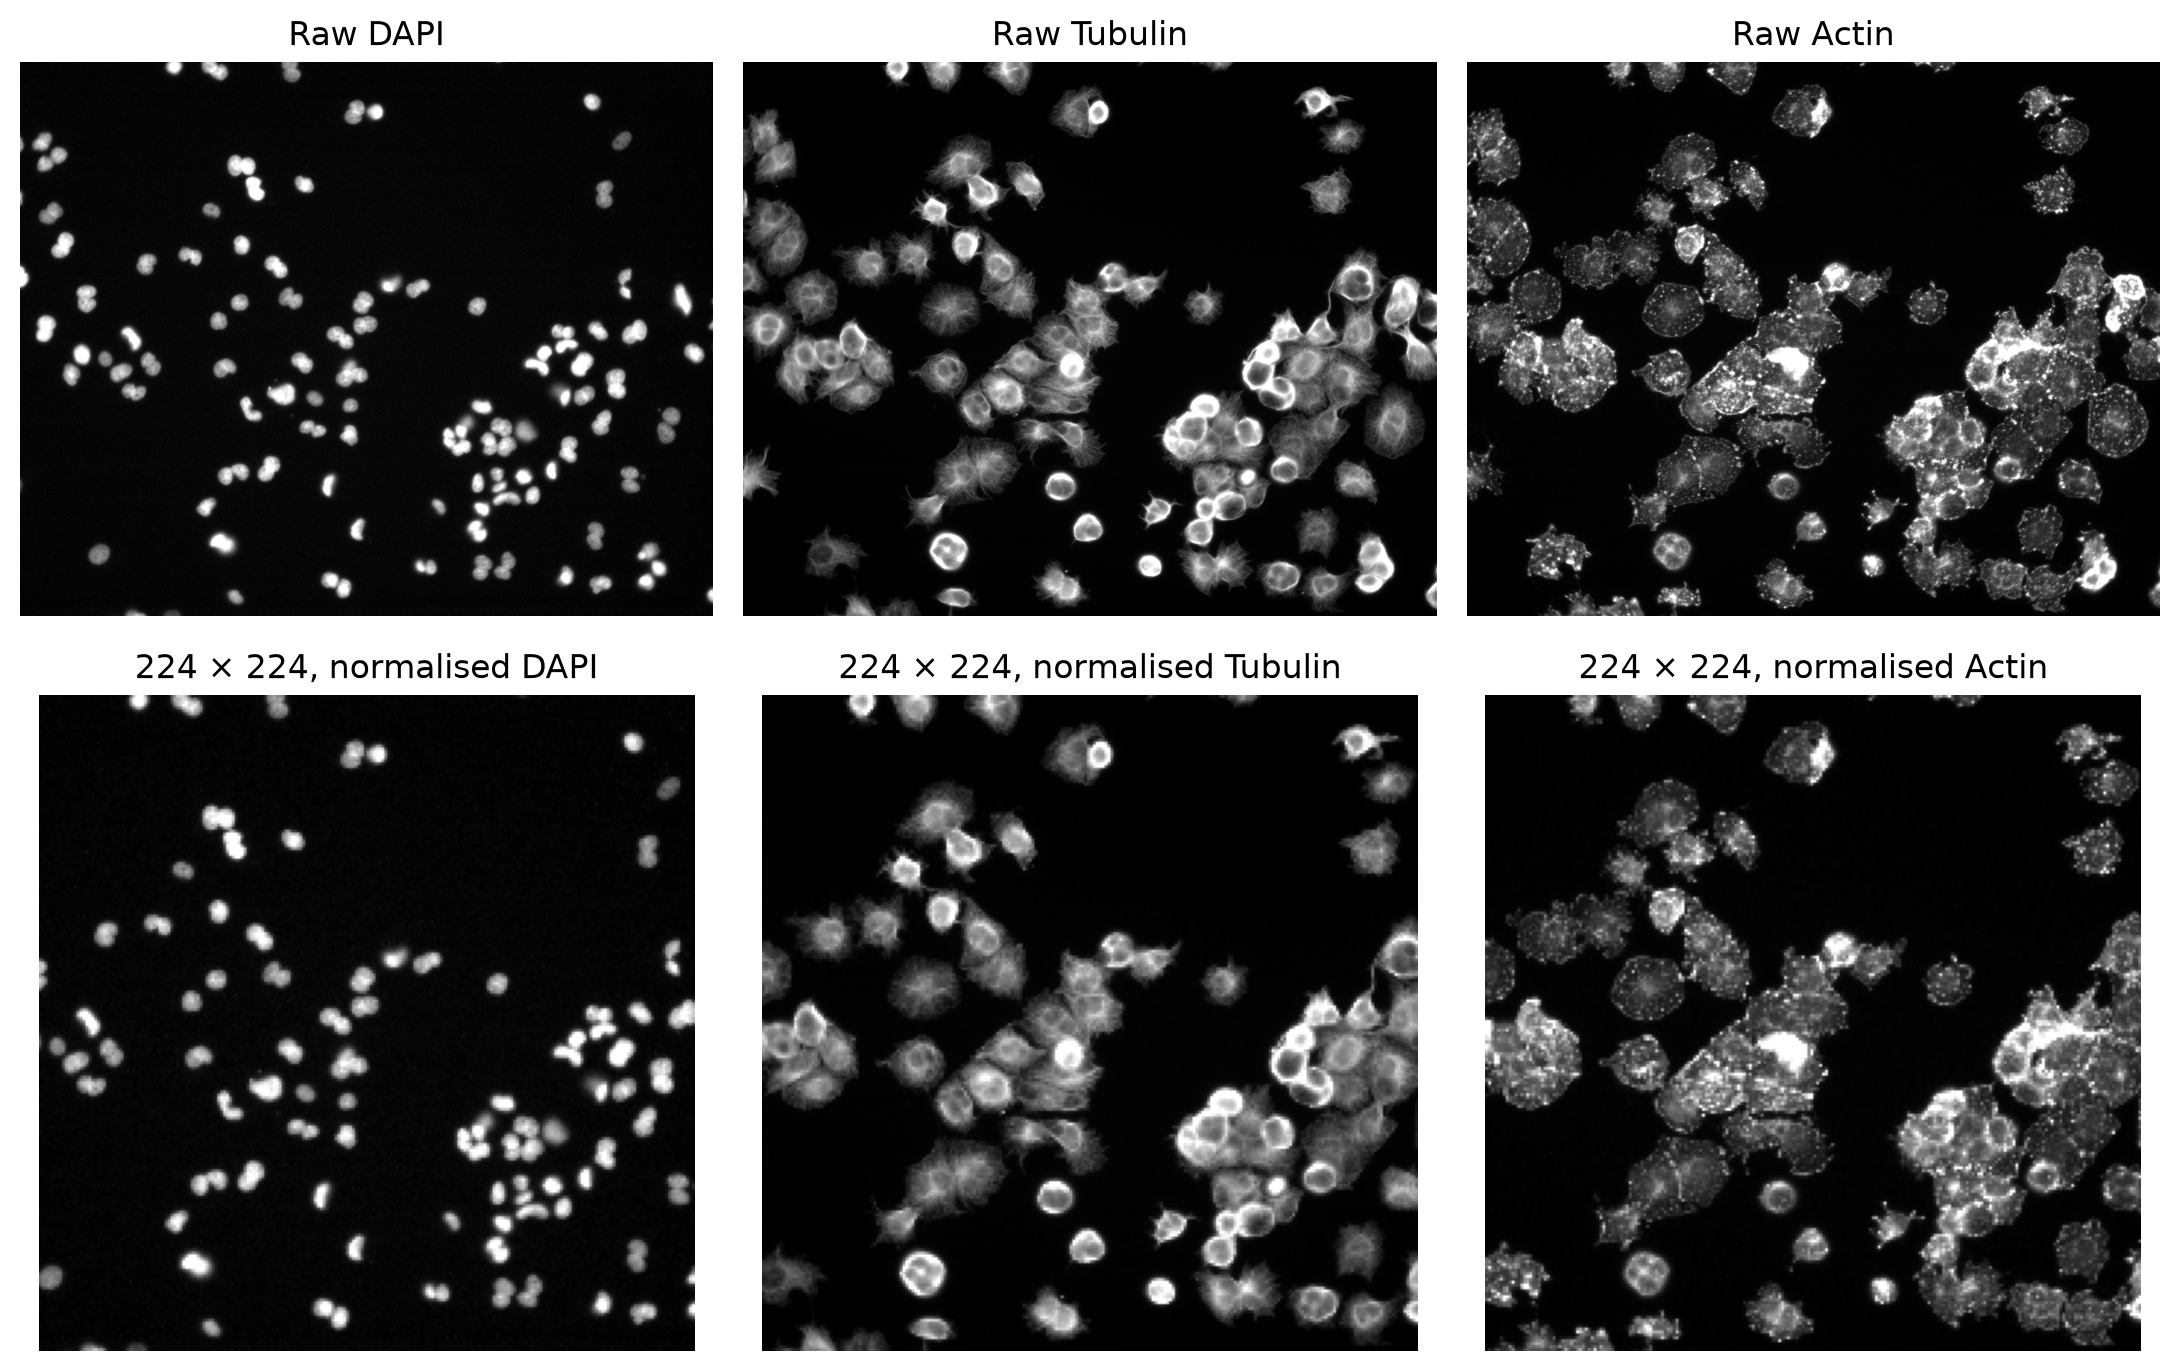

In [32]:
examples = metadata.groupby("moa", sort=True).sample(n=1, random_state=42)
examples = examples.sort_values("moa")
examples = examples[:3]

channels = ["DAPI", "Tubulin", "Actin"]
def read_channels(row):
    arrays = [tifffile.imread(project_root/"data/raw/images"/
              row[f"Image_PathName_{c}"]/row[f"Image_FileName_{c}"])
              for c in channels]
    return np.stack(arrays).astype(np.float32)

fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3 * len(examples)))
for i, (_, row) in enumerate(examples.iterrows()):
    raw = read_channels(row)
    for j, channel in enumerate(channels):
        lo, hi = np.percentile(raw[j], [1, 99])
        axes[i, j].imshow(raw[j], cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
        axes[i, j].set_title(f"{row.moa} — {row.compound}\n{channel}", fontsize=9)
        axes[i, j].axis("off")
# savefig(fig, "examples_by_moa")

row = examples.iloc[0]
raw = read_channels(row)
processed = eval_transform(torch.from_numpy(raw)).numpy()
assert processed.shape == (3, 224, 224) and np.isfinite(processed).all()
assert processed.min() >= 0 and processed.max() <= 1
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for j, channel in enumerate(channels):
    lo, hi = np.percentile(raw[j], [1, 99])
    axes[0, j].imshow(raw[j], cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
    axes[1, j].imshow(processed[j], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"Raw {channel}")
    axes[1, j].set_title(f"224 × 224, normalised {channel}")
    for ax in axes[:, j]:
        ax.axis("off")
savefig(fig, "preprocessing_example")

The processed example shows that the coarse nuclear, microtubule, and actin morphology remains visible after resizing and centre-cropping.

## LOCO desgin audit

Validation keeps at least two development compounds per MoA in training when possible. Consequently some classes have no validation examples. Counts below quantify this.

In [34]:
dataset = SimpleNamespace(
    metadata=metadata,
    get_compounds=lambda: metadata.compound.unique(),
    get_indices_for_compound=lambda c: metadata.index[metadata.compound.eq(c)].tolist(),
)
split_rows = []
for fold, (dev, test, compound) in enumerate(
        create_loco_folds(dataset, len(dataset.get_compounds()), seed=42), 1):
    train, val = create_validation_split(dataset, dev, seed=42)
    groups = [set(metadata.iloc[idx].compound) for idx in [train, val, test]]

    split_rows.append({
        "fold": fold, "test_compound": compound,
        "train_images": len(train), "val_images": len(val), "test_images": len(test),
        "train_classes": metadata.iloc[train].moa.nunique(),
        "val_classes": metadata.iloc[val].moa.nunique(),
        "missing_val_classes": "; ".join(sorted(set(classes) - set(metadata.iloc[val].moa))),
    })

split_summary = pd.DataFrame(split_rows)
display(split_summary)
split_summary.to_csv(OUT / "split_audit.csv", index=False)

train_set = set(train)
val_set = set(val)
test_set = set(test)

assert not train_set & val_set
assert not train_set & test_set
assert not val_set & test_set
assert train_set | val_set | test_set == set(metadata.index)

train_compounds = set(metadata.iloc[train]["compound"])
val_compounds = set(metadata.iloc[val]["compound"])
test_compounds = set(metadata.iloc[test]["compound"])

assert not train_compounds & val_compounds
assert not train_compounds & test_compounds
assert not val_compounds & test_compounds

,fold,test_compound,train_images,val_images,test_images,train_classes,val_classes,missing_val_classes
0,1,AZ-J,2160,332,36,12,9,Cholesterol-lowering; Eg5 inhibitors; Epithelial
1,2,epothilone B,2224,268,36,12,9,Cholesterol-lowering; Eg5 inhibitors; Microtub...
2,3,AZ841,2196,296,36,12,9,Aurora kinase inhibitors; Cholesterol-lowering...
3,4,AZ-C,820,1624,84,12,10,Cholesterol-lowering; Eg5 inhibitors
4,5,mitoxantrone,880,1624,24,12,10,Cholesterol-lowering; Eg5 inhibitors
5,6,cytochalasin B,2196,308,24,12,9,Actin disruptors; Cholesterol-lowering; Eg5 in...
6,7,vincristine,820,1624,84,12,10,Cholesterol-lowering; Eg5 inhibitors
7,8,alsterpaullone,2152,360,16,12,9,Cholesterol-lowering; Eg5 inhibitors; Kinase i...
8,9,cyclohexamide,892,1600,36,12,9,Cholesterol-lowering; Eg5 inhibitors; Protein ...
9,10,mevinolin/lovastatin,868,1624,36,12,10,Cholesterol-lowering; Eg5 inhibitors


All folds retain all 12 MoA classes for training, but validation contains only 9 or 10 classes. This occurs because each MoA is represented by only two to four compounds. For those classes with only two MoA compounds in development set, holding one out for validation would leave insufficient compound diversity for training, so those classes remain training-only for that fold. Validation macro F1 is consequently only calculated over the classes represented in that validation set.

## Summary

- The analysed subset contains 2,528 three-channel fields of view from 38 compounds and 12 MoA classes.
- Class imbalance motivates class-weight training and the use of macro F1 and balanced accuracy as main metrics.
- The small number of compounds per MoA motivates transfer learning.
- Visual inspection of field of views' examples confirms correct channel loading.
- LOCO protocol successfully separates compounds between training, validation, and test sets,
- LOCO design audit is satisfactory but validation does not cover every class in every fold since splitting protocol keeps at least two development compounds per MoA in training when possible.